In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report,accuracy_score
from joblib import dump, load

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy.stats import mode
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import Binarizer
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.datasets import fetch_openml

from xai_aux import CFCalculations
from xai_aux import simulate_noise_effect

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
2025-01-31 08:41:09.418652: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-31 08:41:09.554595: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-31 08:41:09.939050: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-31 08:41:09.939098: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-31 08:41:09.992405: E external/local_xla/x

In [2]:
warnings.filterwarnings("ignore", message="X has feature names, but RandomForestClassifier was fitted without feature names")
warnings.filterwarnings("ignore", message="X has feature names, but LogisticRegression was fitted without feature names")
warnings.filterwarnings("ignore", message="X does not have valid feature names, but OneHotEncoder was fitted with feature names")
warnings.filterwarnings("ignore", message="X does not have valid feature names, but StandardScaler was fitted with feature names")
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", message=".*At this time, the v2.11\\+ optimizer.*")

In [3]:
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.data

categorical_columns = ["workclass", "education", "marital-status", "occupation",
            "relationship", "race", "sex", "native-country"]
numerical_columnns = [col for col in df.columns if col not in categorical_columns]
df = df[categorical_columns + numerical_columnns]

# Reorder columns: categorical first, numerical after
df = df[categorical_columns + numerical_columnns]
df = df.drop(columns=["fnlwgt","sex","race"])

# Encode target variable
le = LabelEncoder()
adult.target = le.fit_transform(adult.target)

# Convert to NumPy array
y = np.array(adult.target)
df['y'] = y
df = df.dropna()
df= df.sample(frac=0.1)
y = df.pop('y')
y = y.values

num_feat = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
cat_feat = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'native-country']

/nvme/h/lchristodoulou/.conda/envs/pymc5b/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/nvme/h/lchristodoulou/.conda/envs/pymc5b/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/nvme/h/lchristodoulou/.conda/envs/pymc5b/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/nvme/h/lchristodoulou/.conda/envs/pymc5b/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization has

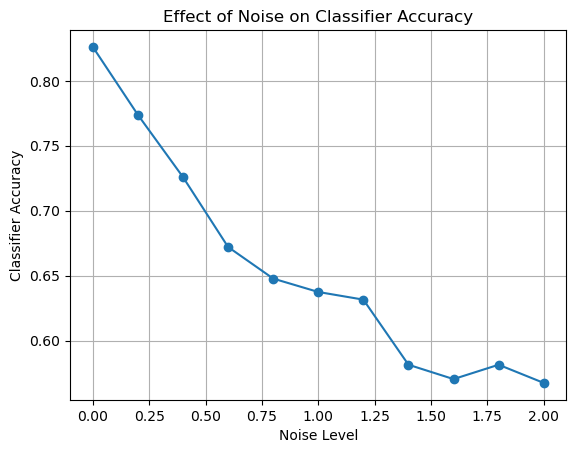

In [4]:
results, datasets = simulate_noise_effect(df, num_feat, cat_feat, y, max_noise=2., step=0.2)
noise_levels, accuracies = zip(*results)
plt.plot(noise_levels, accuracies, marker='o')
plt.xlabel('Noise Level')
plt.ylabel('Classifier Accuracy')
plt.title('Effect of Noise on Classifier Accuracy')
plt.grid()
plt.show()

In [5]:
n_features = len(df.columns)
p = []
for i in cat_feat:
    value_counts = pd.DataFrame(df[i].value_counts()>20)
    p.append(len(value_counts[value_counts[i]].index))

start = 1  # Starting number
polytopes = []
for length in p:
    subarray = list(range(start, start + length))
    polytopes.append(subarray)
    start += length  # Update start for the next subarray

In [6]:
model_results_dict = {}
cf_results_dict = {}
cm_results_dict = {}
cfs_good_indices = {}
for c1, dataset_in in enumerate(datasets):
    print("Working on dataset ", str(c1))
    X = dataset_in[0]
    y = dataset_in[1]
    df = pd.DataFrame(X.values, columns=[str(i) for i in range(n_features)])
    df_train, df_test, y_train, y_test, indices_train, indices_test = train_test_split(df, y, np.arange(len(X)), test_size=0.33, random_state=42)

    # # ommitted variables change
    # df_train = df_train.drop(['4','8','9'], axis=1).rename({'5':'4','6':'5','7':'6'},axis=1)
    # df_test = df_test.drop(['4','8','9'], axis=1).rename({'5':'4','6':'5','7':'6'},axis=1)
    # num_feat = [4,5,6]
    # cat_feat = [0,1,2,3]
    
    # if non_iid:
    #     outlier_indices = np.random.choice(len(df_test), n_samples//10, replace=False)
    #     df_test.iloc[outlier_indices, 5:] *= 5
    
    cf_calc = CFCalculations(df_train, y_train, df_test, y_test, [int(i) for i in range(6)], [int(i) for i in range(6,11)], polytopes) # no constant assummed
    print(pd.DataFrame([(model, metric, value) for (model, metric), value in cf_calc.model_stats.items()], columns=['Model', 'Metric', 'Value']))
    model_results_dict[f"noise_{c1:.0f}"] = cf_calc.model_stats
    cm_results_dict[f"noise_{c1:.0f}"] = cf_calc.cms
    cfs = cf_calc.get_cfs()
    cfs_good_indices[f"noise_{c1:.0f}"] = cf_calc.check_cfs()
    cf_results_dict[f"noise_{c1:.0f}"] = cfs

    dump(cf_calc, "cf_calc_mock_data"+str(mock_data)+"_adult_income.pkl")
    dump(cf_results_dict, "cf_results_dict_mock_data"+str(mock_data)+"_adult_income.pkl")
    dump(model_results_dict, "model_results_dict"+str(mock_data)+"_adult_income.pkl")
    dump(cfs_good_indices, "cfs_good_indices"+str(mock_data)+"_adult_income.pkl")
    # dump(datasets, "datasets_"+str(mock_data)+"_adult_income.pkl")
    print("==================================================================================================")

Working on dataset  0


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 249 seconds.


47/47 [==============================] - 0s 749us/step - loss: 0.4088 - accuracy: 0.8165 - precision: 0.6425
TF Test Accuracy: 81.65%
47/47 [==============================] - 0s 634us/step
  Model     Metric     Value
0    lr   accuracy  0.840589
1    lr  precision  0.836296
2   blr   accuracy  0.840589
3   blr  precision  0.835950
4    rf   accuracy  0.836571
5    rf  precision  0.832508
6    tf   accuracy  0.816477
7    tf  precision  0.816791
Working on lr skl
optimization error - returning original array
optimization error - returning original array
optimization error - returning original array
optimization error - returning original array
optimization error - returning original array
optimization error - returning original array
optimization error - returning original array
optimization error - returning original array
optimization error - returning original array
optimization error - returning original array
optimization error - returning original array
optimization error - retur

KeyboardInterrupt: 

In [7]:
polytopes

[[1, 2, 3, 4, 5, 6],
 [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
 [21, 22, 23, 24, 25, 26],
 [27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39],
 [40, 41, 42, 43, 44, 45],
 [46, 47, 48]]

In [10]:
df_test

,0,1,2,3,4,5,6,7,8,9,10
3909,Private,Some-college,Never-married,Sales,Own-child,United-States,18.0,10.0,0.0,0.0,25.0
2389,Private,HS-grad,Married-civ-spouse,Sales,Husband,United-States,52.0,9.0,0.0,0.0,60.0
4512,Private,Some-college,Never-married,Craft-repair,Not-in-family,United-States,57.0,10.0,0.0,0.0,40.0
2346,State-gov,Masters,Married-civ-spouse,Exec-managerial,Husband,United-States,37.0,14.0,0.0,0.0,38.0
4081,Private,Some-college,Never-married,Handlers-cleaners,Unmarried,United-States,42.0,10.0,0.0,625.0,40.0
...,...,...,...,...,...,...,...,...,...,...,...
4414,Private,HS-grad,Married-civ-spouse,Craft-repair,Husband,United-States,54.0,9.0,0.0,2051.0,40.0
3038,Private,9th,Never-married,Craft-repair,Other-relative,Guatemala,24.0,5.0,0.0,0.0,58.0
2407,Federal-gov,Bachelors,Married-civ-spouse,Prof-specialty,Husband,United-States,56.0,13.0,0.0,0.0,40.0
218,Private,7th-8th,Married-civ-spouse,Craft-repair,Husband,United-States,28.0,4.0,0.0,0.0,30.0
